# Applied Agentic AI — Solved Retail Assignment
## Shelf Availability Exception Resolution

**Scenario:** NorthStar Retail  
**Format:** Task-wise reference solution  
**Target completion time:** 120 minutes  
**Facilitator:** Dr Darshan Ingle

This solution deliberately uses the same engineering patterns taught in class—architecture scoring, typed outputs, grounded retrieval, tool contracts, LangGraph routing and failure resilience—on a different retail operations use case.

## Learning objectives

By the end of the exercise, you will be able to:

- choose a workflow, agent, hybrid or traditional architecture using explicit criteria;
- define validated input and output contracts;
- keep evidence collection separate from decision synthesis;
- orchestrate a retail decision through a LangGraph state machine;
- expose degraded data and route unsafe cases to verification;
- evaluate behaviour with assertions and export auditable artifacts.

In [1]:
from __future__ import annotations

from collections import Counter
from enum import Enum
from pathlib import Path
from typing import Any, Dict, List, Optional, TypedDict
import json
import math
import re
import time
import warnings

warnings.filterwarnings("ignore", message="urllib3 v2 only supports OpenSSL.*")
warnings.filterwarnings("ignore", message="The default value of `allowed_objects`.*")
warnings.filterwarnings("ignore", module=r"langgraph\.cache\.base.*")

from pydantic import BaseModel, Field, field_validator
from langchain_core._api.deprecation import LangChainPendingDeprecationWarning
warnings.filterwarnings("ignore", category=LangChainPendingDeprecationWarning)
from langgraph.graph import StateGraph, START, END

ARTIFACT_DIR = Path("retail_assignment_outputs")
ARTIFACT_DIR.mkdir(exist_ok=True)

print("Environment ready")

Environment ready


## Task 1 — Choose the architecture

The five-axis model is reused from the architecture-decision notebook. The use case needs dynamic branching and policy grounding, but actions remain bounded and high-impact decisions require verification. A **hybrid workflow** is therefore more appropriate than an unconstrained autonomous agent.

In [2]:
def recommend_architecture(scores: Dict[str, int]) -> Dict[str, Any]:
    required = {"task_complexity", "latency_tolerance", "cost_tolerance", "risk_tolerance", "update_frequency"}
    if set(scores) != required:
        raise ValueError(f"Expected axes: {sorted(required)}")
    if any(not 1 <= value <= 5 for value in scores.values()):
        raise ValueError("Every architecture score must be between 1 and 5")

    average = sum(scores.values()) / len(scores)
    hybrid_override = scores["task_complexity"] >= 4 and scores["risk_tolerance"] >= 4
    if hybrid_override:
        choice = "HYBRID_WORKFLOW"
    elif average >= 4:
        choice = "AGENT"
    elif average >= 2.6:
        choice = "FIXED_WORKFLOW"
    else:
        choice = "TRADITIONAL_SOFTWARE"
    return {"scores": scores, "average": round(average, 2), "recommended_architecture": choice}


architecture_decision = recommend_architecture({
    "task_complexity": 4,
    "latency_tolerance": 3,
    "cost_tolerance": 3,
    "risk_tolerance": 5,
    "update_frequency": 4,
})
architecture_decision

{'scores': {'task_complexity': 4,
  'latency_tolerance': 3,
  'cost_tolerance': 3,
  'risk_tolerance': 5,
  'update_frequency': 4},
 'average': 3.8,
 'recommended_architecture': 'HYBRID_WORKFLOW'}

**Decision:** use deterministic validation, tools, policy retrieval and quality gates around a bounded decision router. This preserves explainability and operational control while allowing the path to change according to the evidence.

## Task 2 — Define trustworthy contracts

The input and output schemas prevent free-form drift. The final answer can be validated before it reaches another service or a store associate.

In [3]:
class Action(str, Enum):
    REPLENISH_FROM_BACKROOM = "REPLENISH_FROM_BACKROOM"
    WAIT_FOR_INBOUND = "WAIT_FOR_INBOUND"
    TRANSFER_FROM_NEARBY_STORE = "TRANSFER_FROM_NEARBY_STORE"
    OFFER_APPROVED_SUBSTITUTE = "OFFER_APPROVED_SUBSTITUTE"
    ESCALATE_FOR_VERIFICATION = "ESCALATE_FOR_VERIFICATION"


class ShelfException(BaseModel):
    case_id: str
    store_id: str
    sku: str
    shelf_qty: int = Field(ge=0)
    shelf_capacity: int = Field(gt=0)
    expected_units_next_4h: int = Field(ge=0)

    @field_validator("case_id", "store_id", "sku")
    @classmethod
    def non_empty(cls, value: str) -> str:
        value = value.strip().upper()
        if not value:
            raise ValueError("identifier cannot be empty")
        return value


class ResolutionDecision(BaseModel):
    case_id: str
    action: Action
    confidence: float = Field(ge=0, le=1)
    rationale: str
    evidence: List[str]
    policy_refs: List[str]
    risk_flags: List[str] = Field(default_factory=list)
    escalation_required: bool = False


print("Contracts ready:", [member.value for member in Action])

Contracts ready: ['REPLENISH_FROM_BACKROOM', 'WAIT_FOR_INBOUND', 'TRANSFER_FROM_NEARBY_STORE', 'OFFER_APPROVED_SUBSTITUTE', 'ESCALATE_FOR_VERIFICATION']


## Task 3 — Build the evidence layer

The data below represents four retail services. In production these functions could be REST endpoints or tools exposed through an MCP server. The graph depends on their stable contracts, not on their transport.

In [4]:
CATALOG = {
    "COF-ARAB-12": {"name": "Arabica Ground Coffee 12 oz", "category": "COFFEE", "price": 8.99},
    "OAT-ORG-32": {"name": "Organic Oat Drink 32 oz", "category": "PLANT_MILK", "price": 4.49},
    "NUT-SNK-06": {"name": "Roasted Nut Snack 6 pack", "category": "SNACK", "price": 6.99},
    "SOAP-ALOE-3": {"name": "Aloe Hand Soap 3 pack", "category": "PERSONAL_CARE", "price": 5.99},
    "SOAP-OAT-3": {"name": "Oat Hand Soap 3 pack", "category": "PERSONAL_CARE", "price": 6.49},
}

INVENTORY = {
    ("S042", "COF-ARAB-12"): {"backroom_qty": 8, "source": "live", "age_minutes": 1},
    ("S108", "OAT-ORG-32"): {"backroom_qty": 0, "source": "live", "age_minutes": 1},
    ("S205", "NUT-SNK-06"): {"backroom_qty": 0, "source": "live", "age_minutes": 2},
    ("S309", "SOAP-ALOE-3"): {"backroom_qty": 5, "source": "live", "age_minutes": 1},
}

INBOUND = {
    ("S042", "COF-ARAB-12"): {"eta_hours": 18, "confirmed": True},
    ("S108", "OAT-ORG-32"): {"eta_hours": 3, "confirmed": True},
    ("S205", "NUT-SNK-06"): {"eta_hours": 16, "confirmed": True},
    ("S309", "SOAP-ALOE-3"): {"eta_hours": 20, "confirmed": False},
}

TRANSFER_CANDIDATES = {
    "NUT-SNK-06": [
        {"store_id": "S208", "distance_miles": 7.2, "available_qty": 10},
        {"store_id": "S214", "distance_miles": 18.0, "available_qty": 20},
    ]
}

SUBSTITUTES = {
    "SOAP-ALOE-3": [
        {"sku": "SOAP-OAT-3", "category": "PERSONAL_CARE", "price": 6.49, "available_qty": 8}
    ]
}

CACHE = {
    ("S309", "SOAP-ALOE-3"): {"backroom_qty": 5, "source": "cache", "age_minutes": 10}
}

TRANSIENT_FAILURES = Counter({("S309", "SOAP-ALOE-3"): 3})


def validate_sku(sku: str) -> None:
    if sku not in CATALOG:
        raise ValueError(f"Unknown SKU: {sku}")


def get_inventory_snapshot(store_id: str, sku: str) -> Dict[str, Any]:
    validate_sku(sku)
    key = (store_id, sku)
    if TRANSIENT_FAILURES[key] > 0:
        TRANSIENT_FAILURES[key] -= 1
        raise TimeoutError("inventory service timed out")
    if key not in INVENTORY:
        raise LookupError(f"No inventory record for {store_id}/{sku}")
    return dict(INVENTORY[key])


def get_inbound_eta(store_id: str, sku: str) -> Dict[str, Any]:
    validate_sku(sku)
    return dict(INBOUND.get((store_id, sku), {"eta_hours": None, "confirmed": False}))


def find_transfer_candidates(sku: str) -> List[Dict[str, Any]]:
    validate_sku(sku)
    return [dict(item) for item in TRANSFER_CANDIDATES.get(sku, [])]


def find_substitutes(sku: str) -> List[Dict[str, Any]]:
    validate_sku(sku)
    return [dict(item) for item in SUBSTITUTES.get(sku, [])]


print("Tool contracts ready")

Tool contracts ready


### Grounded policy retrieval

The retriever uses local TF-IDF vectors so the notebook is executable without an API key. Its interface is intentionally similar to an embedding-backed retriever and can be replaced by `OpenAIEmbeddings` plus a vector store without changing the graph.

In [5]:
POLICIES = [
    {"id": "POL-INV-01", "text": "Use backroom stock first when verified backroom quantity covers the shelf gap plus two units of safety stock."},
    {"id": "POL-INB-02", "text": "Wait for inbound only when ETA is four hours or less and current shelf cover is at least two hours."},
    {"id": "POL-TRN-03", "text": "A donor store must be within 15 miles and retain at least four units after the transfer."},
    {"id": "POL-SUB-04", "text": "A substitute must be in the same category, within 15 percent price variance and have at least three units available."},
    {"id": "POL-SAF-05", "text": "Cached inventory may support a provisional action only when no older than 15 minutes; mark it for associate verification."},
]

def _tokens(text: str) -> List[str]:
    return re.findall(r"[a-z0-9]+", text.lower())


def _tfidf_vectors(texts: List[str]) -> List[Dict[str, float]]:
    tokenised = [_tokens(text) for text in texts]
    document_frequency = Counter(token for tokens in tokenised for token in set(tokens))
    n_docs = len(texts)
    vectors = []
    for tokens in tokenised:
        counts = Counter(tokens)
        total = max(len(tokens), 1)
        vectors.append({
            token: (count / total) * (math.log((1 + n_docs) / (1 + document_frequency[token])) + 1)
            for token, count in counts.items()
        })
    return vectors


def _cosine(left: Dict[str, float], right: Dict[str, float]) -> float:
    dot = sum(value * right.get(token, 0.0) for token, value in left.items())
    left_norm = math.sqrt(sum(value * value for value in left.values()))
    right_norm = math.sqrt(sum(value * value for value in right.values()))
    return dot / (left_norm * right_norm) if left_norm and right_norm else 0.0


_policy_vectors = _tfidf_vectors([p["text"] for p in POLICIES])


def retrieve_policy(query: str, top_k: int = 3) -> List[Dict[str, Any]]:
    query_vector = _tfidf_vectors([query])[0]
    scores = [_cosine(query_vector, policy_vector) for policy_vector in _policy_vectors]
    ranked = sorted(range(len(POLICIES)), key=lambda i: scores[i], reverse=True)[:top_k]
    return [dict(POLICIES[i], score=round(float(scores[i]), 3)) for i in ranked]


retrieve_policy("nearby donor store transfer distance and remaining stock")

[{'id': 'POL-TRN-03',
  'text': 'A donor store must be within 15 miles and retain at least four units after the transfer.',
  'score': 0.379},
 {'id': 'POL-INV-01',
  'text': 'Use backroom stock first when verified backroom quantity covers the shelf gap plus two units of safety stock.',
  'score': 0.16},
 {'id': 'POL-SUB-04',
  'text': 'A substitute must be in the same category, within 15 percent price variance and have at least three units available.',
  'score': 0.061}]

## Task 4 — Add resilience

The wrapper makes a bounded number of attempts. If live inventory still fails, it uses a fresh cache entry and makes the degradation explicit. An absent or stale cache produces an error that the graph will escalate.

In [6]:
def inventory_with_resilience(store_id: str, sku: str, max_attempts: int = 3) -> Dict[str, Any]:
    errors = []
    for attempt in range(1, max_attempts + 1):
        try:
            result = get_inventory_snapshot(store_id, sku)
            return {**result, "attempts": attempt, "degraded": False}
        except (TimeoutError, ConnectionError) as exc:
            errors.append(str(exc))
            time.sleep(0.01 * attempt)  # compressed back-off for a classroom lab

    cached = CACHE.get((store_id, sku))
    if cached and cached["age_minutes"] <= 15:
        return {**cached, "attempts": max_attempts, "degraded": True, "errors": errors}
    raise RuntimeError(f"Inventory unavailable after {max_attempts} attempts and no fresh cache exists")


print(inventory_with_resilience("S042", "COF-ARAB-12"))

{'backroom_qty': 8, 'source': 'live', 'age_minutes': 1, 'attempts': 1, 'degraded': False}


## Task 5 — Orchestrate with LangGraph

The graph is a constrained hybrid:

1. validate the case;
2. collect evidence from tools;
3. retrieve relevant policy;
4. route to one bounded decision path;
5. apply a quality gate;
6. finalise a typed answer.

The design is intentionally smaller than a multi-agent supervisor because the operational actions are known and mutually exclusive.

In [7]:
class ResolutionState(TypedDict, total=False):
    case: Dict[str, Any]
    inventory: Dict[str, Any]
    inbound: Dict[str, Any]
    transfers: List[Dict[str, Any]]
    substitutes: List[Dict[str, Any]]
    policies: List[Dict[str, Any]]
    route: str
    draft: Dict[str, Any]
    validation_errors: List[str]
    final: Dict[str, Any]


def validate_node(state: ResolutionState) -> ResolutionState:
    try:
        case = ShelfException(**state["case"])
        validate_sku(case.sku)
        return {"case": case.model_dump(), "validation_errors": []}
    except Exception as exc:
        return {"validation_errors": [str(exc)], "route": "INVALID"}


def collect_evidence_node(state: ResolutionState) -> ResolutionState:
    case = state["case"]
    try:
        inventory = inventory_with_resilience(case["store_id"], case["sku"])
    except Exception as exc:
        inventory = {"unavailable": True, "error": str(exc), "degraded": True}
    return {
        "inventory": inventory,
        "inbound": get_inbound_eta(case["store_id"], case["sku"]),
        "transfers": find_transfer_candidates(case["sku"]),
        "substitutes": find_substitutes(case["sku"]),
    }


def policy_node(state: ResolutionState) -> ResolutionState:
    case = state["case"]
    query = (
        f"Resolve shelf availability for {case['sku']}: backroom inventory, inbound ETA, "
        "nearby transfer, substitute and cached-data safety"
    )
    return {"policies": retrieve_policy(query, top_k=5)}


def router_node(state: ResolutionState) -> ResolutionState:
    if state.get("validation_errors"):
        return {"route": "INVALID"}
    case, inv, inbound = state["case"], state["inventory"], state["inbound"]
    if inv.get("unavailable"):
        return {"route": "ESCALATE"}
    shelf_gap = case["shelf_capacity"] - case["shelf_qty"]
    if inv.get("backroom_qty", 0) >= shelf_gap + 2:
        return {"route": "BACKROOM"}
    shelf_cover_hours = 4 if case["expected_units_next_4h"] == 0 else (case["shelf_qty"] / case["expected_units_next_4h"]) * 4
    if inbound.get("confirmed") and inbound.get("eta_hours") is not None and inbound["eta_hours"] <= 4 and shelf_cover_hours >= 2:
        return {"route": "INBOUND"}
    eligible = [
        item for item in state["transfers"]
        if item["distance_miles"] <= 15 and item["available_qty"] - shelf_gap >= 4
    ]
    if eligible:
        return {"route": "TRANSFER"}
    product = CATALOG[case["sku"]]
    eligible_subs = [
        item for item in state["substitutes"]
        if item["category"] == product["category"]
        and abs(item["price"] - product["price"]) / product["price"] <= 0.15
        and item["available_qty"] >= 3
    ]
    return {"route": "SUBSTITUTE" if eligible_subs else "ESCALATE"}


def route_after_router(state: ResolutionState) -> str:
    return state["route"]

In [8]:
def policy_ids(state: ResolutionState, *ids: str) -> List[str]:
    retrieved = {item["id"] for item in state.get("policies", [])}
    return [item for item in ids if item in retrieved]


def invalid_node(state: ResolutionState) -> ResolutionState:
    return {"draft": {
        "action": Action.ESCALATE_FOR_VERIFICATION.value,
        "confidence": 0.0,
        "rationale": "The case failed identifier or schema validation.",
        "evidence": state.get("validation_errors", ["validation failed"]),
        "policy_refs": ["POL-SAF-05"],
        "risk_flags": ["INVALID_INPUT"],
        "escalation_required": True,
    }}


def backroom_node(state: ResolutionState) -> ResolutionState:
    inv = state["inventory"]
    degraded = inv.get("degraded", False)
    refs = policy_ids(state, "POL-INV-01", *( ["POL-SAF-05"] if degraded else [] ))
    return {"draft": {
        "action": Action.REPLENISH_FROM_BACKROOM.value,
        "confidence": 0.72 if degraded else 0.95,
        "rationale": "Verified backroom quantity covers the shelf gap plus safety stock." if not degraded else "Fresh cached inventory indicates enough backroom stock; verify before moving units.",
        "evidence": [f"backroom_qty={inv['backroom_qty']}", f"source={inv['source']}", f"age_minutes={inv['age_minutes']}"],
        "policy_refs": refs,
        "risk_flags": ["INVENTORY_CACHE_USED", "VERIFY_BEFORE_ACTION"] if degraded else [],
        "escalation_required": degraded,
    }}


def inbound_node(state: ResolutionState) -> ResolutionState:
    inbound = state["inbound"]
    return {"draft": {
        "action": Action.WAIT_FOR_INBOUND.value,
        "confidence": 0.91,
        "rationale": "Current shelf cover is sufficient and a confirmed delivery is due within four hours.",
        "evidence": [f"shelf_qty={state['case']['shelf_qty']}", f"eta_hours={inbound['eta_hours']}", "inbound_confirmed=True"],
        "policy_refs": policy_ids(state, "POL-INB-02"),
        "risk_flags": [],
        "escalation_required": False,
    }}


def transfer_node(state: ResolutionState) -> ResolutionState:
    case = state["case"]
    gap = case["shelf_capacity"] - case["shelf_qty"]
    candidates = sorted(
        [x for x in state["transfers"] if x["distance_miles"] <= 15 and x["available_qty"] - gap >= 4],
        key=lambda x: x["distance_miles"],
    )
    donor = candidates[0]
    return {"draft": {
        "action": Action.TRANSFER_FROM_NEARBY_STORE.value,
        "confidence": 0.88,
        "rationale": f"{donor['store_id']} is within range and retains the required safety stock after transfer.",
        "evidence": [f"donor_store={donor['store_id']}", f"distance_miles={donor['distance_miles']}", f"available_qty={donor['available_qty']}"],
        "policy_refs": policy_ids(state, "POL-TRN-03"),
        "risk_flags": [],
        "escalation_required": False,
    }}


def substitute_node(state: ResolutionState) -> ResolutionState:
    original = CATALOG[state["case"]["sku"]]
    eligible = [x for x in state["substitutes"] if x["category"] == original["category"] and abs(x["price"]-original["price"])/original["price"] <= 0.15 and x["available_qty"] >= 3]
    best = eligible[0]
    return {"draft": {
        "action": Action.OFFER_APPROVED_SUBSTITUTE.value,
        "confidence": 0.84,
        "rationale": f"{best['sku']} meets category, price-variance and availability rules.",
        "evidence": [f"substitute_sku={best['sku']}", f"price={best['price']}", f"available_qty={best['available_qty']}"],
        "policy_refs": policy_ids(state, "POL-SUB-04"),
        "risk_flags": [],
        "escalation_required": False,
    }}


def escalate_node(state: ResolutionState) -> ResolutionState:
    return {"draft": {
        "action": Action.ESCALATE_FOR_VERIFICATION.value,
        "confidence": 0.2,
        "rationale": "The available evidence does not support a safe automated recommendation.",
        "evidence": [json.dumps(state.get("inventory", {}), sort_keys=True)],
        "policy_refs": policy_ids(state, "POL-SAF-05") or ["POL-SAF-05"],
        "risk_flags": ["INSUFFICIENT_VERIFIED_EVIDENCE"],
        "escalation_required": True,
    }}

In [9]:
def quality_gate_node(state: ResolutionState) -> ResolutionState:
    draft = dict(state["draft"])
    problems = []
    if not draft.get("evidence"):
        problems.append("MISSING_EVIDENCE")
    if not draft.get("policy_refs"):
        problems.append("MISSING_POLICY_REFERENCE")
    if problems:
        draft.update({
            "action": Action.ESCALATE_FOR_VERIFICATION.value,
            "confidence": min(draft.get("confidence", 0.0), 0.3),
            "risk_flags": sorted(set(draft.get("risk_flags", []) + problems)),
            "escalation_required": True,
            "rationale": "Quality gate rejected the draft: " + ", ".join(problems),
        })
    return {"draft": draft}


def finalise_node(state: ResolutionState) -> ResolutionState:
    case_id = state.get("case", {}).get("case_id", state.get("case", {}).get("case_id", "UNKNOWN"))
    decision = ResolutionDecision(case_id=case_id, **state["draft"])
    return {"final": decision.model_dump(mode="json")}


builder = StateGraph(ResolutionState)
builder.add_node("validate", validate_node)
builder.add_node("collect_evidence", collect_evidence_node)
builder.add_node("retrieve_policy", policy_node)
builder.add_node("route", router_node)
builder.add_node("invalid", invalid_node)
builder.add_node("backroom", backroom_node)
builder.add_node("inbound", inbound_node)
builder.add_node("transfer", transfer_node)
builder.add_node("substitute", substitute_node)
builder.add_node("escalate", escalate_node)
builder.add_node("quality_gate", quality_gate_node)
builder.add_node("finalise", finalise_node)

builder.add_edge(START, "validate")
builder.add_conditional_edges("validate", lambda s: "INVALID" if s.get("validation_errors") else "VALID", {"INVALID": "invalid", "VALID": "collect_evidence"})
builder.add_edge("collect_evidence", "retrieve_policy")
builder.add_edge("retrieve_policy", "route")
builder.add_conditional_edges("route", route_after_router, {
    "INVALID": "invalid", "BACKROOM": "backroom", "INBOUND": "inbound",
    "TRANSFER": "transfer", "SUBSTITUTE": "substitute", "ESCALATE": "escalate",
})
for node in ("invalid", "backroom", "inbound", "transfer", "substitute", "escalate"):
    builder.add_edge(node, "quality_gate")
builder.add_edge("quality_gate", "finalise")
builder.add_edge("finalise", END)

resolution_graph = builder.compile()
print("Graph compiled")

Graph compiled


### Inspect the graph

In an interactive notebook, the Mermaid representation can be displayed as an image if the environment supports it. The text representation below keeps this solution portable.

In [10]:
print(resolution_graph.get_graph().draw_mermaid())

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	validate(validate)
	collect_evidence(collect_evidence)
	retrieve_policy(retrieve_policy)
	route(route)
	invalid(invalid)
	backroom(backroom)
	inbound(inbound)
	transfer(transfer)
	substitute(substitute)
	escalate(escalate)
	quality_gate(quality_gate)
	finalise(finalise)
	__end__([<p>__end__</p>]):::last
	__start__ --> validate;
	backroom --> quality_gate;
	collect_evidence --> retrieve_policy;
	escalate --> quality_gate;
	inbound --> quality_gate;
	invalid --> quality_gate;
	quality_gate --> finalise;
	retrieve_policy --> route;
	route -. &nbsp;BACKROOM&nbsp; .-> backroom;
	route -. &nbsp;ESCALATE&nbsp; .-> escalate;
	route -. &nbsp;INBOUND&nbsp; .-> inbound;
	route -. &nbsp;INVALID&nbsp; .-> invalid;
	route -. &nbsp;SUBSTITUTE&nbsp; .-> substitute;
	route -. &nbsp;TRANSFER&nbsp; .-> transfer;
	substitute --> quality_gate;
	transfer --> quality_gate;
	validate -. &nbsp;VALID&nbsp; .-> colle

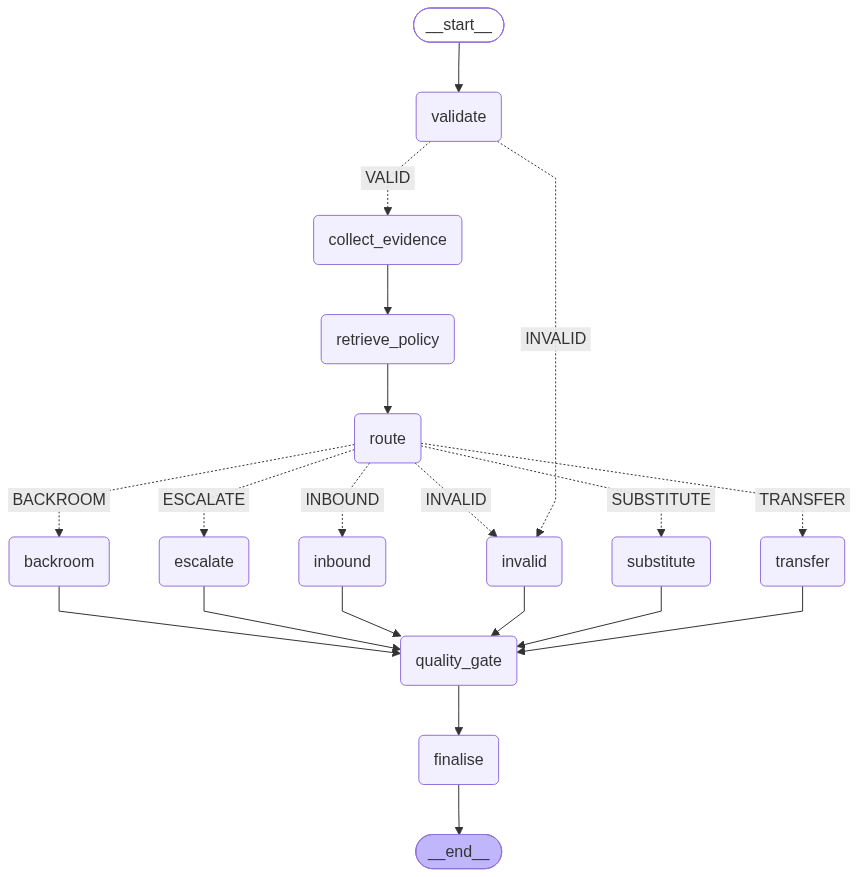

In [11]:
# To see the graph’s connection visually
from IPython.display import Image,display
display(Image(resolution_graph.get_graph().draw_mermaid_png()))

## Task 6 — Evaluate and export

Four cases exercise the backroom, inbound, transfer and degraded-cache paths. The fourth case is important: the recommendation remains provisional and explicitly requests verification.

In [12]:
TEST_CASES = [
    {"case_id": "EX-101", "store_id": "S042", "sku": "COF-ARAB-12", "shelf_qty": 0, "shelf_capacity": 6, "expected_units_next_4h": 8},
    {"case_id": "EX-102", "store_id": "S108", "sku": "OAT-ORG-32", "shelf_qty": 4, "shelf_capacity": 8, "expected_units_next_4h": 4},
    {"case_id": "EX-103", "store_id": "S205", "sku": "NUT-SNK-06", "shelf_qty": 0, "shelf_capacity": 6, "expected_units_next_4h": 5},
    {"case_id": "EX-104", "store_id": "S309", "sku": "SOAP-ALOE-3", "shelf_qty": 0, "shelf_capacity": 3, "expected_units_next_4h": 3},
]

results = []
for case in TEST_CASES:
    output = resolution_graph.invoke({"case": case})
    results.append(output["final"])

for result in results:
    print(f"{result['case_id']}: {result['action']} | confidence={result['confidence']:.2f} | policies={result['policy_refs']} | risks={result['risk_flags']}")

EX-101: REPLENISH_FROM_BACKROOM | confidence=0.95 | policies=['POL-INV-01'] | risks=[]
EX-102: WAIT_FOR_INBOUND | confidence=0.91 | policies=['POL-INB-02'] | risks=[]
EX-103: TRANSFER_FROM_NEARBY_STORE | confidence=0.88 | policies=['POL-TRN-03'] | risks=[]
EX-104: REPLENISH_FROM_BACKROOM | confidence=0.72 | policies=['POL-INV-01', 'POL-SAF-05'] | risks=['INVENTORY_CACHE_USED', 'VERIFY_BEFORE_ACTION']


In [13]:
expected_actions = {
    "EX-101": Action.REPLENISH_FROM_BACKROOM.value,
    "EX-102": Action.WAIT_FOR_INBOUND.value,
    "EX-103": Action.TRANSFER_FROM_NEARBY_STORE.value,
    "EX-104": Action.REPLENISH_FROM_BACKROOM.value,
}

assert {r["case_id"]: r["action"] for r in results} == expected_actions
assert all(r["evidence"] for r in results)
assert all(r["policy_refs"] for r in results)

degraded = next(r for r in results if r["case_id"] == "EX-104")
assert degraded["escalation_required"] is True
assert "INVENTORY_CACHE_USED" in degraded["risk_flags"]
assert degraded["confidence"] < 0.8

print("All behavioural assertions passed")

All behavioural assertions passed


In [14]:
json_path = ARTIFACT_DIR / "retail_exception_results.json"
json_path.write_text(json.dumps(results, indent=2), encoding="utf-8")

summary_lines = [
    "# Retail Shelf Availability Exception Summary",
    "",
    "| Case | Action | Confidence | Policy references | Risk flags |",
    "|---|---|---:|---|---|",
]
for r in results:
    summary_lines.append(
        f"| {r['case_id']} | {r['action']} | {r['confidence']:.2f} | "
        f"{', '.join(r['policy_refs'])} | {', '.join(r['risk_flags']) or '—'} |"
    )
summary_lines += [
    "",
    "## Limitation",
    "The local retriever and in-memory tools are suitable for a bounded lab, not for production freshness, access control or scale.",
    "",
    "## Production-hardening recommendation",
    "Expose governed tools through authenticated REST/MCP services, add tracing and service-level objectives, version policy chunks, and evaluate routing against labelled retail exceptions before enabling operational actions.",
]
summary_path = ARTIFACT_DIR / "retail_exception_summary.md"
summary_path.write_text("\n".join(summary_lines), encoding="utf-8")

print("Exported:", json_path)
print("Exported:", summary_path)

Exported: retail_assignment_outputs/retail_exception_results.json
Exported: retail_assignment_outputs/retail_exception_summary.md


## Engineering debrief

### Why this is not a full autonomous agent

The action space is bounded, the evidence sources are known and the operational risk is meaningful. Deterministic gates and conditional routes are easier to test and audit than an unconstrained planning loop.

### Where an LLM can add value

An LLM can convert associate notes into the typed `ShelfException` contract, improve policy-query formulation and produce a concise explanation. It should not invent inventory or bypass the quality gate.

### REST, MCP and framework choice

- The in-memory functions model stable tool contracts. REST is appropriate when a small number of controlled applications call them.
- MCP becomes valuable when several AI hosts must discover the same centrally governed retail tools and schemas.
- LangGraph is justified because branching, state, validation and failure paths must remain visible.

### Production next steps

Add authenticated services, tool-level authorisation, tracing, idempotency, policy versioning, offline evaluations, human approval for provisional actions, and operational SLOs.

## Optional extension — structured LLM synthesis

If an approved model endpoint and API key are available, add a final synthesis node that receives only the validated tool evidence and retrieved policy chunks, and returns `ResolutionDecision` as structured output. Keep the deterministic quality gate after the model. The core solution intentionally remains executable without external credentials.

## Completed deliverables

- Executable LangGraph workflow
- Four passing retail test cases
- Typed and grounded decisions
- Explicit degraded-cache behaviour
- `retail_exception_results.json`
- `retail_exception_summary.md`

**Happy learning.**